# Archetypal Analysis (AA) on the Mouse embryonic brain dataset
This notebook applies AA on the mouse embryonic brain scRNA+ATAC dataset. Prior to this analysis, data should be processed correctly and contained within processed_data/ folder. See ArchVelo_data_preparation.ipynb for details.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import os

In [4]:
import scanpy as sc

In [5]:
import ArchVelo as av

In [6]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'
outdir = model_outdir+'archetypes/'
os.makedirs(outdir, exist_ok = True)
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)

In [7]:
num_comps = 10

# Read in data

In [8]:
# preprocessed ATAC for ArchVelo
atac = sc.read_h5ad(data_outdir+'adata_atac_raw.h5ad')

In [9]:
# preprocessed RNA for ArchVelo
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [11]:
XC, S = av.apply_AA_no_test(atac, 
                  k = num_comps,
                  outdir = outdir, 
                  )

Applying AA...
[13328, 11673, 16154, 10265, 928, 10312, 3976, 12431, 13504, 6264]
[13328, 11673, 16154, 10265, 928, 10312, 3976, 12431, 13504, 6264]

Principal Convex Hull Analysis / Archetypal Analysis
A 10 component model will be fitted
To stop algorithm press control C

-----------+------------+------------+-------------+------------+------------+------------+------------+
 Iteration | Expl. var. | Cost func. | Delta SSEf. |        muC |    mualpha |        muS |  Time(s)   
-----------+------------+------------+-------------+------------+------------+------------+------------+
         1 |     0.0055 | 5.1329e+07 | 1.8722e-01 | 1.9349e-01 | 6.1917e+00 | 4.6146e+00 |     7.0000 

         2 |     0.0127 | 5.0956e+07 | 7.3211e-03 | 1.1980e+00 | 3.8338e+01 | 7.1431e+00 |     6.0000 

         3 |     0.0142 | 5.0877e+07 | 1.5496e-03 | 2.3181e-01 | 2.3738e+02 | 5.5285e+00 |     6.0000 

         4 |     0.0150 | 5.0834e+07 | 8.4666e-04 | 1.4353e+00 | 1.4698e+03 | 4.2789e+00 |     6.000

In [10]:
XC = pd.read_csv(outdir+'cell_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])
adata_rna.obs[['A_'+str(i) for i in range(num_comps)]] = XC.values

In [11]:
%matplotlib inline

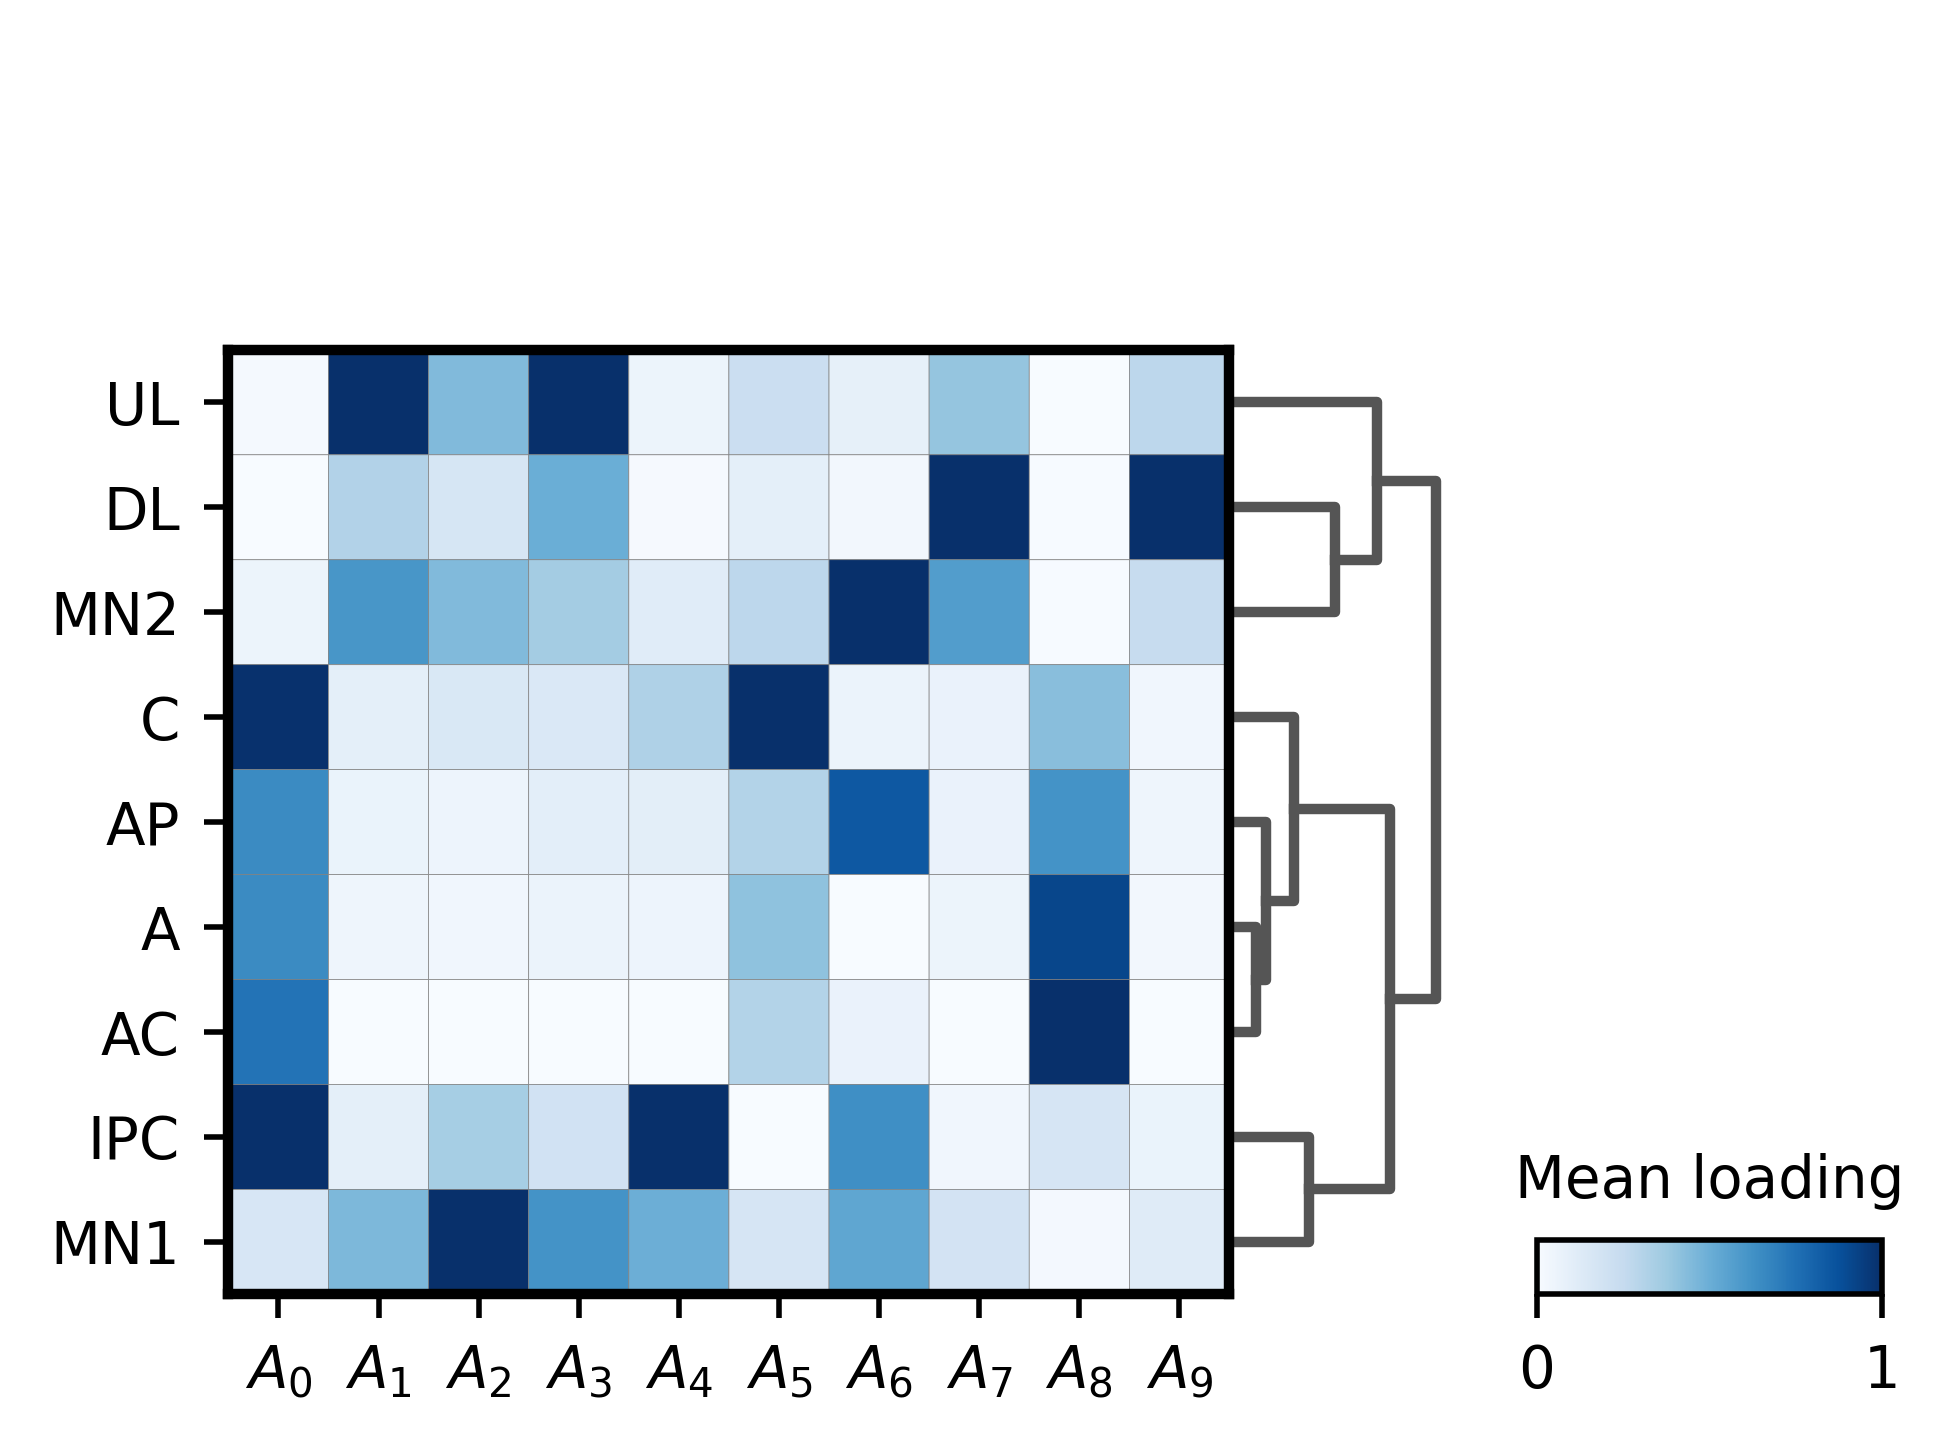

In [13]:
# 10 comps
fig, ax = plt.subplots(1,1,dpi = 500, figsize = (4,3))
g = sc.pl.matrixplot(adata_rna, ['A_'+str(i) for i in range(num_comps)],
                     groupby = 'cell_type_new', 
                     standard_scale = 'var', 
                     #return_fig=True,
                     show = False,
                     dendrogram = True, cmap = 'Blues', swap_axes = False,
                     ax = ax,
                     colorbar_title = 'Mean loading')
g['mainplot_ax'].set_xticks(np.arange(0,num_comps)+0.5, 
                            ['$A_'+str(i)+'$' for i in range(num_comps)],
                           rotation = 0)
#g['color_legend_ax'].set_position([0,1.5,0.1,0.1])
plt.tight_layout()
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.png', dpi = 600)
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.svg', dpi = 600)
#g.show()